# Constrained Clustering Evaluation (PCKMeans Phase with 2D & 3D Visualizations)

This notebook demonstrates the step-by-step pipeline execution of the **Conversational Constrained Clustering (C3)** system. It generates **high-contrast 2D and 3D visualization charts** at each stage, highlighting Must-Link (solid green) and Cannot-Link (dashed red) constraints, contrasting the embedding space before/after ITML metric learning, and showcasing final clustered partitions.

### Step 1: Imports and Environment Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import re
import json
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Ensure the root project path is in sys.path
sys.path.append(os.path.abspath('..'))

from src.dataset.loader import load_dataset
from src.embeddings.local_embeddings import SentenceTransformerEmbeddings
from src.pipeline import ConversationalClusteringPipeline
from src.agent.cloud_agent import GitHubModelsAgent, OpenAIAgent, GeminiAgent
from src.agent.local_agent import OllamaLocalAgent
from src.evaluation.metrics import compute_ari, compute_nmi, compute_acc

warnings.filterwarnings("ignore")

# Configurations
NUM_SAMPLES = 50
BATCH_SIZE = 25
RANDOM_STATE = 42

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN", "")
print("Environment and imports set up successfully!")

Environment and imports set up successfully!


### Step 2: Configure Generator Agent
We set up the LLM agent. It will prioritize GitHub Models (`gpt-4o-mini`), followed by OpenAI, Gemini, Ollama, and finally fallback to a Mock Agent for offline/testing runs.

In [2]:
generator_agent = None
if GITHUB_TOKEN:
    generator_agent = GitHubModelsAgent(api_key=GITHUB_TOKEN, model_name="gpt-4o-mini", verbose=False)
elif os.getenv("OPENAI_API_KEY"):
    generator_agent = OpenAIAgent(model_name="gpt-4o-mini", verbose=False)
elif os.getenv("GEMINI_API_KEY"):
    generator_agent = GeminiAgent(model_name="gemini-1.5-flash", verbose=False)
else:
    try:
        generator_agent = OllamaLocalAgent(base_url="http://localhost:11434", model_name="qwen2.5-coder:latest", verbose=False)
    except Exception:
        pass

if not generator_agent:
    from tests.test_pipeline import MockLLMAgent
    generator_agent = MockLLMAgent()
    print("LLM APIs not configured. Fallback to MockLLMAgent for dry run.")
else:
    print(f"Using Generator Agent: {generator_agent.__class__.__name__}")

Using Generator Agent: GitHubModelsAgent


### Step 3: Load Dataset & Generate Sentence Embeddings

In [3]:
dataset_path = "../data/arxiv_processed_sample.json"
if not os.path.exists(dataset_path):
    dataset_path = "../data/arxiv_processed.json"

dataset = load_dataset(dataset_path)
texts = dataset.get_texts()
true_labels = dataset.get_aspect_labels("category")

print(f"Loaded {len(texts)} documents.")
print("Example document:", texts[0][:150] + "...")

# Precompute Sentence Embeddings
emb_provider = SentenceTransformerEmbeddings()
raw_embeddings = emb_provider.embed_texts(texts)
print(f"Generated base embeddings. Shape: {raw_embeddings.shape}")

Loaded 249 documents.
Example document: On the Markov trace for Temperley--Lieb algebras of type $E_n$. We show that there is a unique Markov trace on the tower of Temperley--Lieb type quoti...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generated base embeddings. Shape: (249, 384)


### Step 4: Define 2D and 3D Projection Plotting Helpers
We define our plotting helper functions. They project high-dimensional embeddings to 2D/3D using PCA. The scatter colors have been updated to be highly contrastive and vivid (`cmap="Set1"`, `alpha=0.9`, `edgecolors='#1e293b'`), making it much easier to see the data distribution, sampled anchors, and Must-Link/Cannot-Link lines.

In [4]:
def plot_embeddings_2d_3d(embeddings, labels, title_prefix, sampled_indices=None, ml_pairs=None, cl_pairs=None, random_state=42):
    from sklearn.decomposition import PCA
    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    pca_2d = PCA(n_components=2, random_state=random_state)
    coords_2d = pca_2d.fit_transform(embeddings)
    
    pca_3d = PCA(n_components=3, random_state=random_state)
    coords_3d = pca_3d.fit_transform(embeddings)
    
    # Custom vibrant palette
    vibrant_colors = ['#2563eb', '#f97316', '#db2777', '#0d9488', '#7c3aed', '#06b6d4', '#e11d48', '#b45309']
    cmap_custom = ListedColormap(vibrant_colors)
    
    fig = plt.figure(figsize=(16, 7.5))
    
    # --- 2D Subplot ---
    ax1 = fig.add_subplot(121)
    ax1.set_facecolor('#f8fafc')
    scatter1 = ax1.scatter(
        coords_2d[:, 0], coords_2d[:, 1], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.6, s=85
    )
    
    if sampled_indices is not None:
        sampled_coords = coords_2d[sampled_indices]
        ax1.scatter(
            sampled_coords[:, 0], sampled_coords[:, 1],
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=150, zorder=5, label='Sampled Anchors'
        )
        
    if ml_pairs is not None:
        for u, v in ml_pairs:
            ax1.plot(
                [coords_2d[u, 0], coords_2d[v, 0]], 
                [coords_2d[u, 1], coords_2d[v, 1]], 
                color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
            )
    if cl_pairs is not None:
        for u, v in cl_pairs:
            ax1.plot(
                [coords_2d[u, 0], coords_2d[v, 0]], 
                [coords_2d[u, 1], coords_2d[v, 1]], 
                color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
            )
            
    ax1.set_title(f"{title_prefix} - 2D PCA", fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC 1')
    ax1.set_ylabel('PC 2')
    ax1.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
    if sampled_indices is not None:
        ax1.legend(loc='best')
        
    # --- 3D Subplot ---
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_facecolor('#f8fafc')
    scatter2 = ax2.scatter(
        coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.5, s=65
    )
    
    if sampled_indices is not None:
        sampled_coords_3d = coords_3d[sampled_indices]
        ax2.scatter(
            sampled_coords_3d[:, 0], sampled_coords_3d[:, 1], sampled_coords_3d[:, 2],
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=120, zorder=5
        )
        
    if ml_pairs is not None:
        for u, v in ml_pairs:
            ax2.plot(
                [coords_3d[u, 0], coords_3d[v, 0]], 
                [coords_3d[u, 1], coords_3d[v, 1]], 
                [coords_3d[u, 2], coords_3d[v, 2]], 
                color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
            )
    if cl_pairs is not None:
        for u, v in cl_pairs:
            ax2.plot(
                [coords_3d[u, 0], coords_3d[v, 0]], 
                [coords_3d[u, 1], coords_3d[v, 1]], 
                [coords_3d[u, 2], coords_3d[v, 2]], 
                color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
            )
            
    ax2.set_title(f"{title_prefix} - 3D PCA", fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC 1')
    ax2.set_ylabel('PC 2')
    ax2.set_zlabel('PC 3')
    
    plt.tight_layout()
    plt.show()

def plot_itml_comparison(embs_before, embs_after, labels, title, sampled_indices, ml_pairs, cl_pairs, random_state=42):
    from sklearn.decomposition import PCA
    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt
    
    # 2D Projections
    pca2_before = PCA(n_components=2, random_state=random_state)
    coords2_before = pca2_before.fit_transform(embs_before)
    
    pca2_after = PCA(n_components=2, random_state=random_state)
    coords2_after = pca2_after.fit_transform(embs_after)
    
    # 3D Projections
    pca3_before = PCA(n_components=3, random_state=random_state)
    coords3_before = pca3_before.fit_transform(embs_before)
    
    pca3_after = PCA(n_components=3, random_state=random_state)
    coords3_after = pca3_after.fit_transform(embs_after)
    
    # Custom vibrant palette
    vibrant_colors = ['#2563eb', '#f97316', '#db2777', '#0d9488', '#7c3aed', '#06b6d4', '#e11d48', '#b45309']
    cmap_custom = ListedColormap(vibrant_colors)
    
    # Create a single large 2x2 grid figure
    fig = plt.figure(figsize=(16, 14))
    
    # --- ROW 1: 2D Projection ---
    # Col 1: 2D Before
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.set_facecolor('#f8fafc')
    scatter_2d_before = ax1.scatter(
        coords2_before[:, 0], coords2_before[:, 1], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.6, s=85
    )
    if sampled_indices is not None:
        ax1.scatter(
            coords2_before[sampled_indices, 0], coords2_before[sampled_indices, 1], 
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=150, zorder=5, label='Sampled Anchors'
        )
    for u, v in ml_pairs:
        ax1.plot(
            [coords2_before[u, 0], coords2_before[v, 0]], 
            [coords2_before[u, 1], coords2_before[v, 1]], 
            color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
        )
    for u, v in cl_pairs:
        ax1.plot(
            [coords2_before[u, 0], coords2_before[v, 0]], 
            [coords2_before[u, 1], coords2_before[v, 1]], 
            color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
        )
    ax1.set_title('2D Projection: Before ITML', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
    ax1.legend(loc='best')
    
    # Col 2: 2D After
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.set_facecolor('#f8fafc')
    scatter_2d_after = ax2.scatter(
        coords2_after[:, 0], coords2_after[:, 1], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.6, s=85
    )
    if sampled_indices is not None:
        ax2.scatter(
            coords2_after[sampled_indices, 0], coords2_after[sampled_indices, 1], 
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=150, zorder=5, label='Sampled Anchors'
        )
    for u, v in ml_pairs:
        ax2.plot(
            [coords2_after[u, 0], coords2_after[v, 0]], 
            [coords2_after[u, 1], coords2_after[v, 1]], 
            color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
        )
    for u, v in cl_pairs:
        ax2.plot(
            [coords2_after[u, 0], coords2_after[v, 0]], 
            [coords2_after[u, 1], coords2_after[v, 1]], 
            color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
        )
    ax2.set_title('2D Projection: After ITML', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
    ax2.legend(loc='best')
    
    # --- ROW 2: 3D Projection ---
    # Col 1: 3D Before
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.set_facecolor('#f8fafc')
    scatter_3d_before = ax3.scatter(
        coords3_before[:, 0], coords3_before[:, 1], coords3_before[:, 2], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.5, s=65
    )
    if sampled_indices is not None:
        ax3.scatter(
            coords3_before[sampled_indices, 0], coords3_before[sampled_indices, 1], coords3_before[sampled_indices, 2], 
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=120, zorder=5
        )
    for u, v in ml_pairs:
        ax3.plot(
            [coords3_before[u, 0], coords3_before[v, 0]], 
            [coords3_before[u, 1], coords3_before[v, 1]], 
            [coords3_before[u, 2], coords3_before[v, 2]], 
            color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
        )
    for u, v in cl_pairs:
        ax3.plot(
            [coords3_before[u, 0], coords3_before[v, 0]], 
            [coords3_before[u, 1], coords3_before[v, 1]], 
            [coords3_before[u, 2], coords3_before[v, 2]], 
            color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
        )
    ax3.set_title('3D Projection: Before ITML', fontsize=12, fontweight='bold')
    
    # Col 2: 3D After
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.set_facecolor('#f8fafc')
    scatter_3d_after = ax4.scatter(
        coords3_after[:, 0], coords3_after[:, 1], coords3_after[:, 2], 
        c=labels, cmap=cmap_custom, alpha=0.95, edgecolors='#0f172a', linewidths=0.5, s=65
    )
    if sampled_indices is not None:
        ax4.scatter(
            coords3_after[sampled_indices, 0], coords3_after[sampled_indices, 1], coords3_after[sampled_indices, 2], 
            facecolors='none', edgecolors='#000000', linewidths=2.5, s=120, zorder=5
        )
    for u, v in ml_pairs:
        ax4.plot(
            [coords3_after[u, 0], coords3_after[v, 0]], 
            [coords3_after[u, 1], coords3_after[v, 1]], 
            [coords3_after[u, 2], coords3_after[v, 2]], 
            color='#10b981', linestyle='-', linewidth=2.5, alpha=0.95, zorder=4
        )
    for u, v in cl_pairs:
        ax4.plot(
            [coords3_after[u, 0], coords3_after[v, 0]], 
            [coords3_after[u, 1], coords3_after[v, 1]], 
            [coords3_after[u, 2], coords3_after[v, 2]], 
            color='#ef4444', linestyle='--', linewidth=1.8, alpha=0.95, zorder=4
        )
    ax4.set_title('3D Projection: After ITML', fontsize=12, fontweight='bold')
    
    fig.suptitle(f'{title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### Phase A: Visualize Raw Embeddings (Original Space)
This step projects the initial text embeddings before any constraint feedback or transformation. Points are colored by ground truth categories.

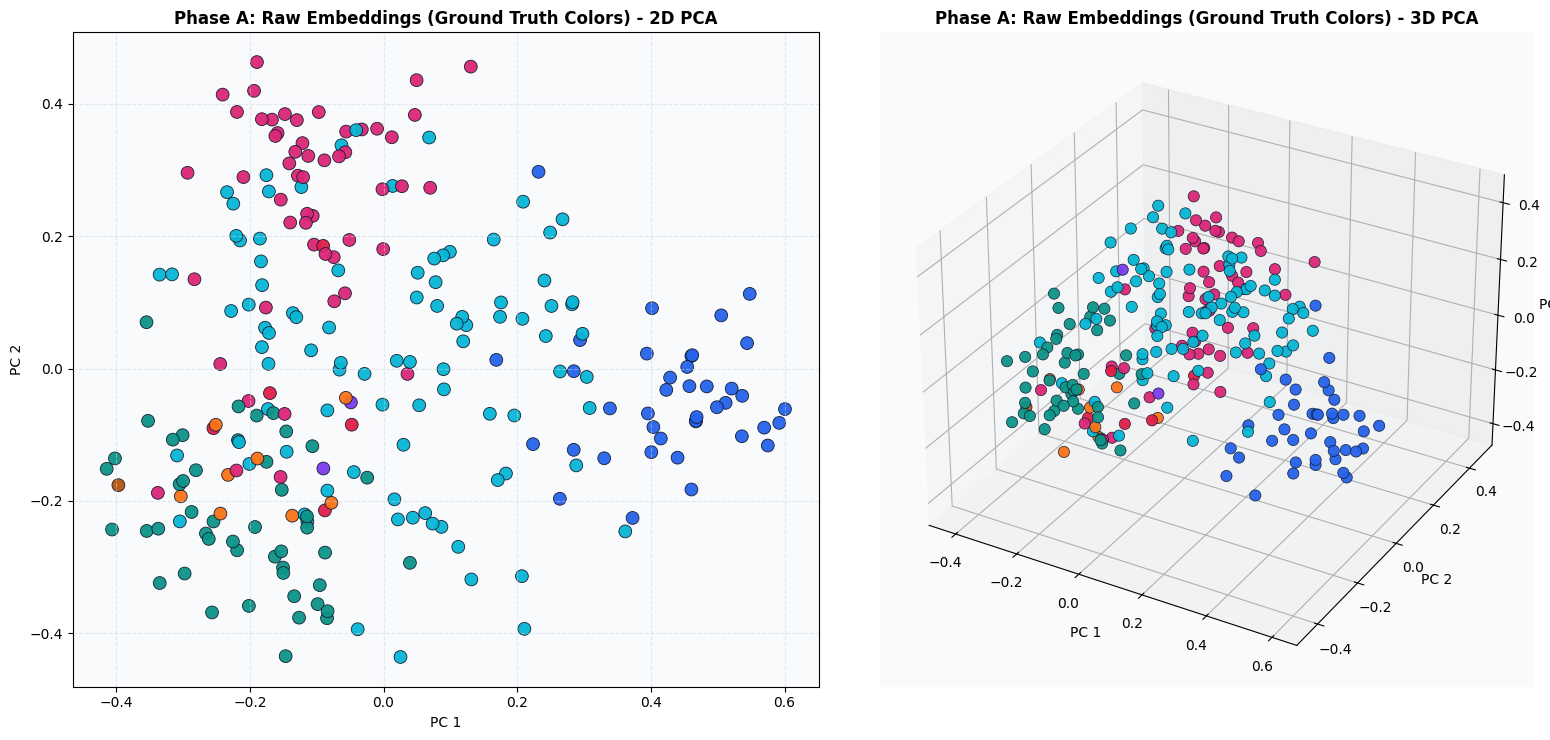

In [5]:
# Convert categories to integers for color coding
unique_types = sorted(list(set(true_labels)))
label_map = {t: i for i, t in enumerate(unique_types)}
y_true = np.array([label_map[l] for l in true_labels])

plot_embeddings_2d_3d(
    embeddings=raw_embeddings,
    labels=y_true,
    title_prefix="Phase A: Raw Embeddings (Ground Truth Colors)",
    random_state=RANDOM_STATE
)

### Step 5: Initialize Pipeline & Representative Sampling (FPS)
Run Farthest Point Sampling to choose the anchors, and run label discovery to get initial assignments.

In [6]:
pipeline = ConversationalClusteringPipeline(
    embedding_provider=emb_provider,
    agent=generator_agent,
    num_samples=NUM_SAMPLES,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE,
    user_intent="Group the documents by primary academic category (e.g., math, physics, computer science).",
    use_qa_phase=False
)
pipeline.set_data(texts)

# Step 5.1: Run FPS
pipeline.sampled_indices = pipeline._farthest_point_sampling(pipeline.embeddings, NUM_SAMPLES)
pipeline.sampled_texts = [pipeline.texts[idx] for idx in pipeline.sampled_indices]

# Step 5.2: Run LLM Discovery
print("Running LLM Label Discovery...")
pipeline._run_label_discovery(pipeline.sampled_indices, is_refinement=False)

Running LLM Label Discovery...


### Step 6: Constraint Extraction
Extract all Must-Link and Cannot-Link constraints directly from the LLM assignments.

In [7]:
from itertools import combinations

pipeline.constraint_ledger = {}
for idx_i, idx_j in combinations(pipeline.sampled_indices, 2):
    lbl_i = pipeline.final_assignments.get(idx_i)
    lbl_j = pipeline.final_assignments.get(idx_j)
    if lbl_i is not None and lbl_j is not None:
        c_type = "Must-Link" if lbl_i == lbl_j else "Cannot-Link"
        pair = (min(idx_i, idx_j), max(idx_i, idx_j))
        pipeline.constraint_ledger[pair] = {"type": c_type, "turn": pipeline.turn}

raw_ml = pipeline.must_link
raw_cl = pipeline.cannot_link
print(f"Extracted raw constraints: {len(raw_ml)} Must-Link and {len(raw_cl)} Cannot-Link constraints.")

Extracted raw constraints: 373 Must-Link and 852 Cannot-Link constraints.


### Phase B1: Visualize Extracted Constraints (Before Filtering)
Plot the raw embedding space, highlighting the sampled anchors, showing **all extracted constraints** (Must-Link as green, Cannot-Link as red) before applying the distance-based filtering.

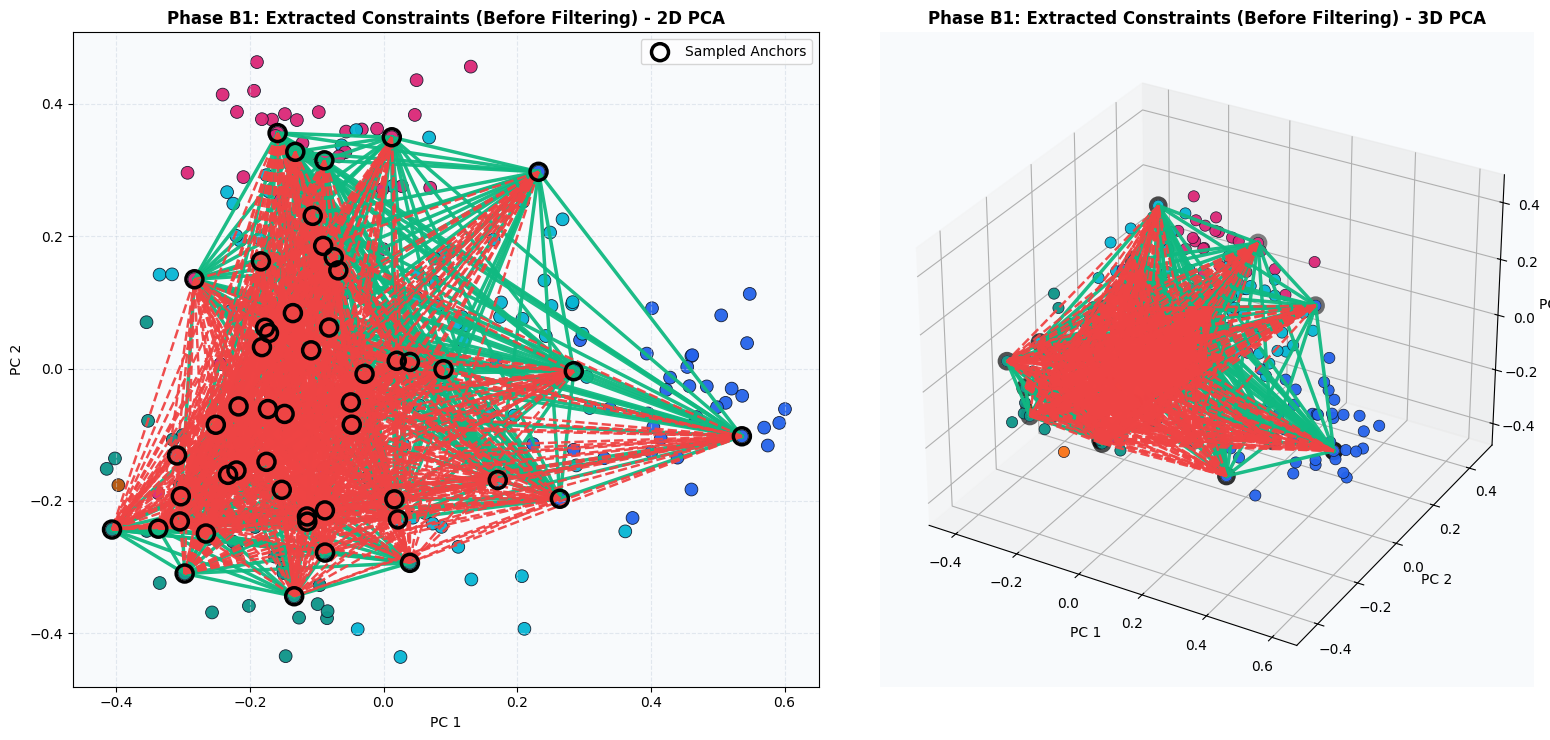

In [8]:
plot_embeddings_2d_3d(
    embeddings=raw_embeddings,
    labels=y_true,
    title_prefix="Phase B1: Extracted Constraints (Before Filtering)",
    sampled_indices=pipeline.sampled_indices,
    ml_pairs=raw_ml,
    cl_pairs=raw_cl,
    random_state=RANDOM_STATE
)

### Step 7: Distance-Based Cannot-Link Filtering
Filter out Cannot-Link constraints that exceed a distance threshold ratio ($0.5$ of average distance) to prevent over-constraining the model.

In [9]:
ratio = 0.5
avg_dist = pipeline._estimate_average_pairwise_distance(pipeline.raw_embeddings)
threshold = ratio * avg_dist
cl_pairs = [pair for pair, info in pipeline.constraint_ledger.items() if info["type"] == "Cannot-Link"]

to_delete = []
for u, v in cl_pairs:
    dist = np.linalg.norm(pipeline.raw_embeddings[u] - pipeline.raw_embeddings[v])
    if dist > threshold:
        to_delete.append((u, v))

for pair in to_delete:
    del pipeline.constraint_ledger[pair]

filtered_ml = pipeline.must_link
filtered_cl = pipeline.cannot_link
print(f"Remaining constraints after distance-based filtering: {len(filtered_ml)} Must-Link and {len(filtered_cl)} Cannot-Link.")

Remaining constraints after distance-based filtering: 373 Must-Link and 0 Cannot-Link.


### Phase B2: Visualize Filtered Constraints
Plot the raw embedding space with the **filtered constraints** (Must-Link as green, Cannot-Link as red) to see which redundant cannot-link pairs were removed.

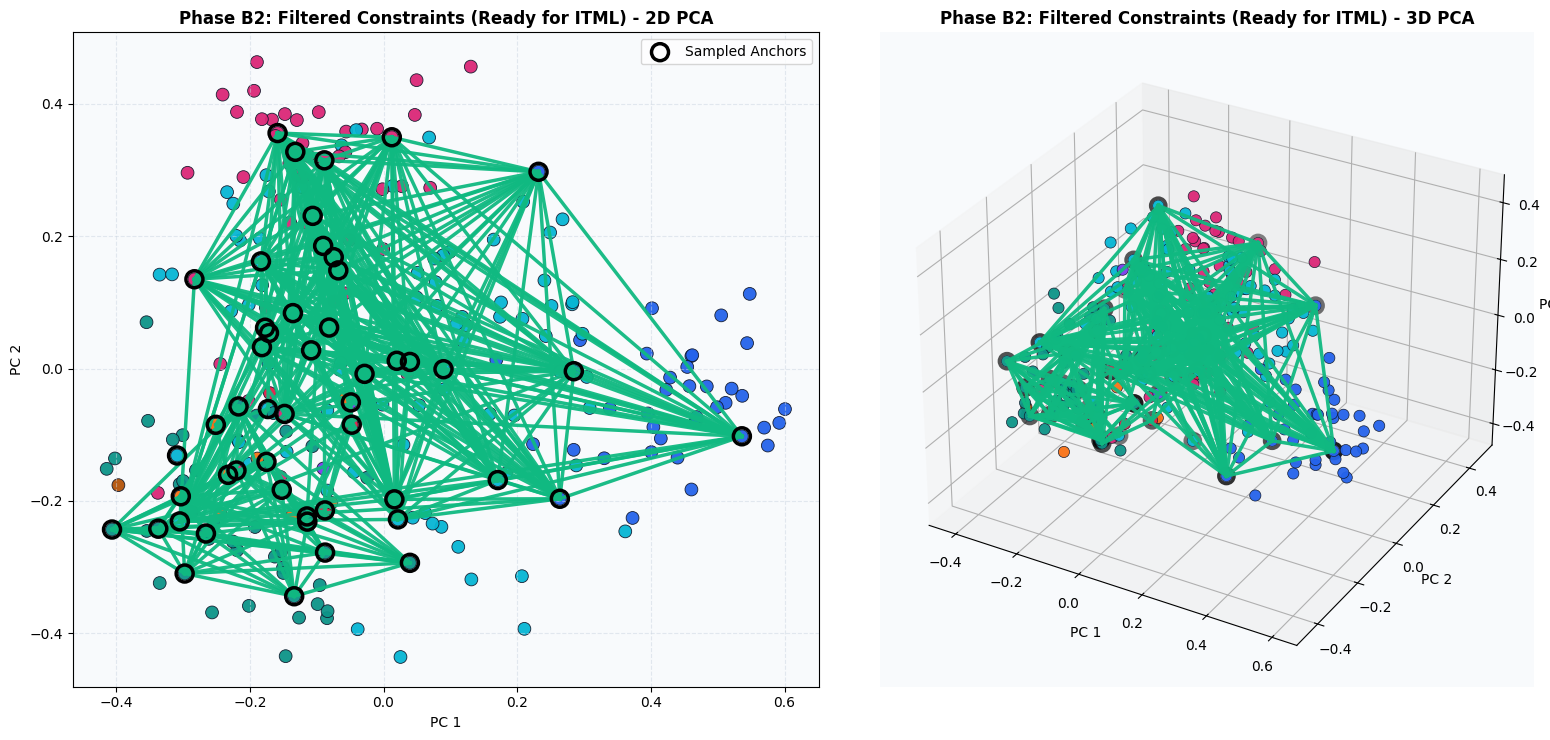

In [10]:
plot_embeddings_2d_3d(
    embeddings=raw_embeddings,
    labels=y_true,
    title_prefix="Phase B2: Filtered Constraints (Ready for ITML)",
    sampled_indices=pipeline.sampled_indices,
    ml_pairs=filtered_ml,
    cl_pairs=filtered_cl,
    random_state=RANDOM_STATE
)

### Step 8: Metric Learning (ITML)
Execute Information-Theoretic Metric Learning (ITML) to adapt the space according to the constraints.

In [11]:
if len(filtered_ml) > 0 or len(filtered_cl) > 0:
    from metric_learn import ITML
    
    pairs = []
    y = []
    for i, j in filtered_ml:
        pairs.append([pipeline.raw_embeddings[i], pipeline.raw_embeddings[j]])
        y.append(1)
    for i, j in filtered_cl:
        pairs.append([pipeline.raw_embeddings[i], pipeline.raw_embeddings[j]])
        y.append(-1)
        
    pairs = np.array(pairs)
    y = np.array(y)
    
    itml_model = ITML(random_state=RANDOM_STATE)
    try:
        itml_model.fit(pairs, y)
        pipeline.embeddings = itml_model.transform(pipeline.raw_embeddings)
        print("ITML transformation successful!")
    except Exception as e:
        print(f"ITML failed: {e}. Fallback to raw.")
        pipeline.embeddings = pipeline.raw_embeddings.copy()
else:
    pipeline.embeddings = pipeline.raw_embeddings.copy()
    print("No constraints available. Skipping ITML.")

ITML transformation successful!


### Phase C: Comparison - Before vs. After ITML Metric Learning
Below are side-by-side comparison charts for **2D Projection** and **3D Projection** of the embedding space before and after ITML. Notice how ITML successfully pulls points connected by solid green lines (Must-Link) closer, and pushes points connected by dashed red lines (Cannot-Link) further apart, forming much tighter and cleaner clusters.

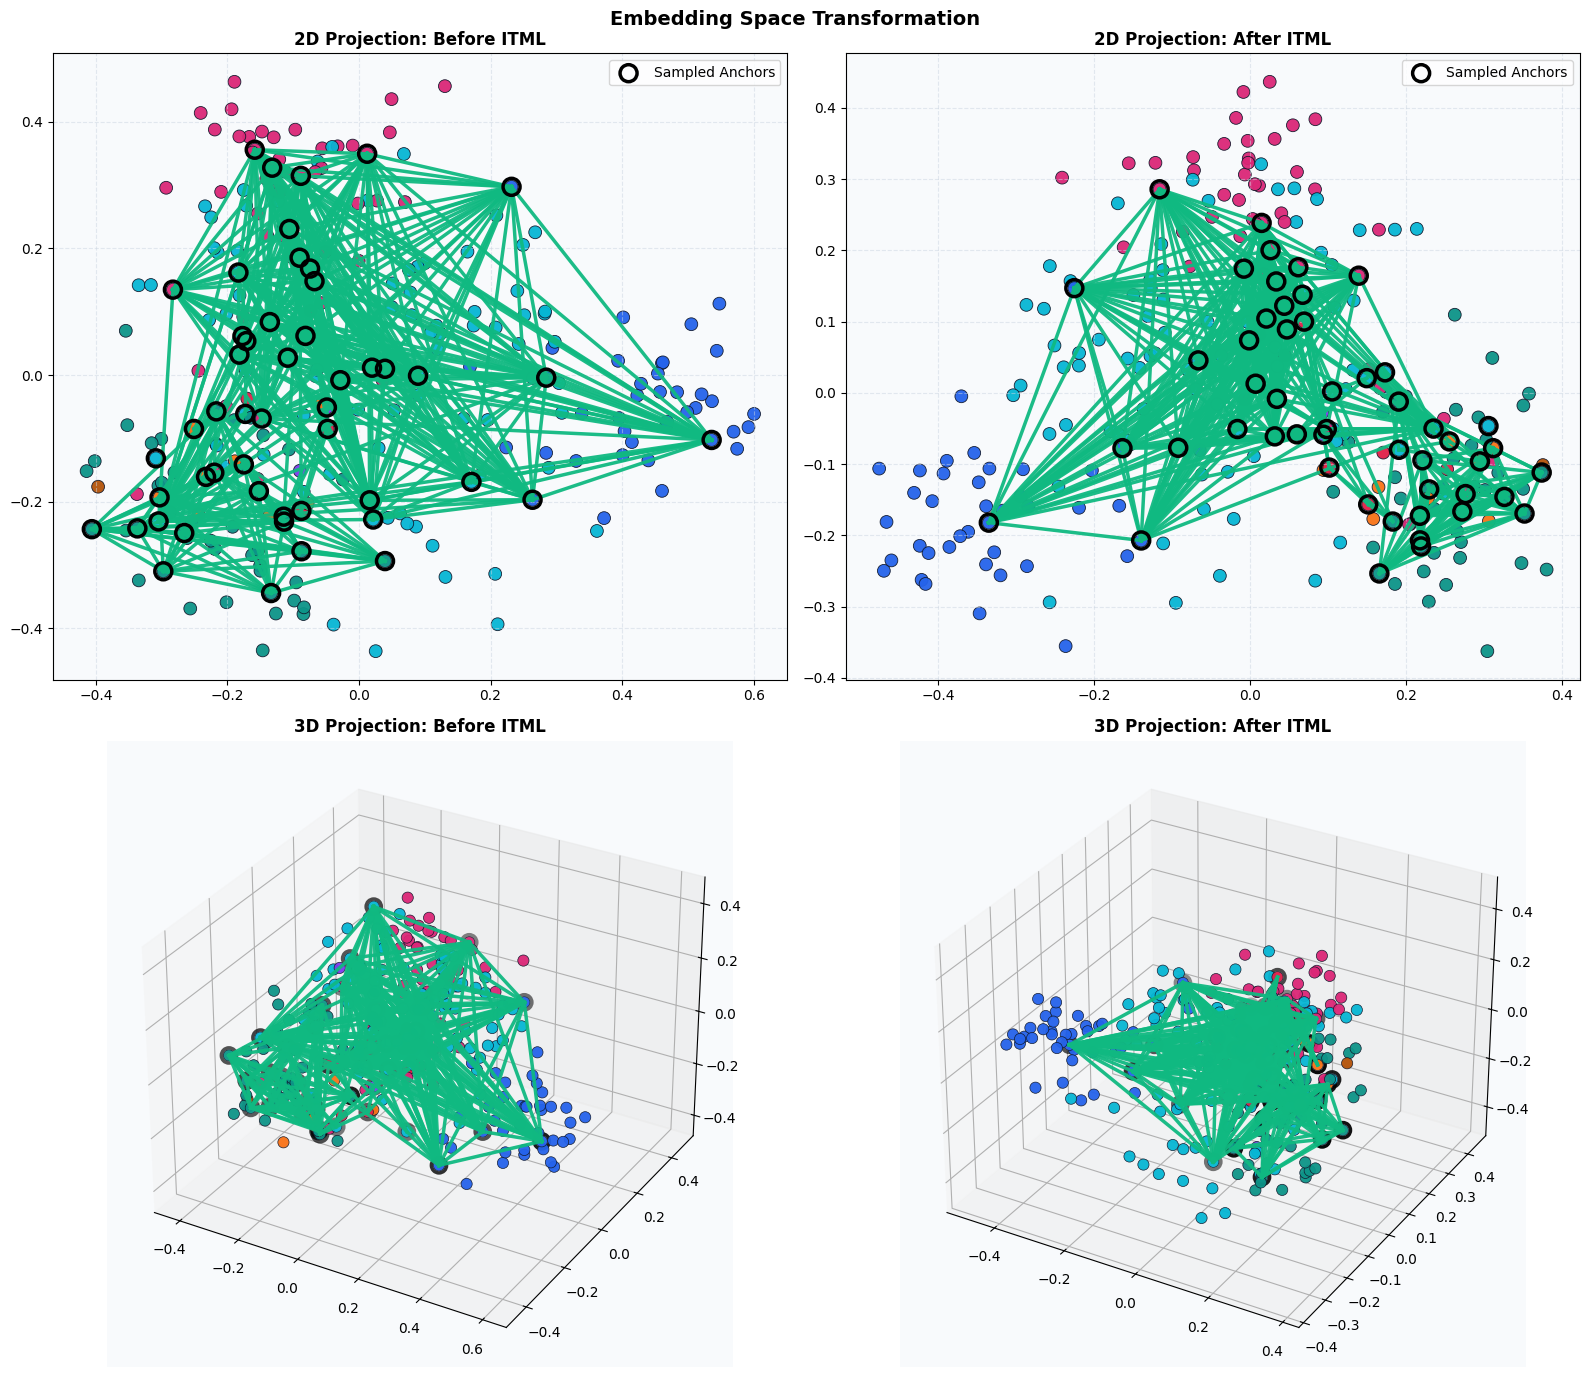

In [12]:
plot_itml_comparison(
    embs_before=raw_embeddings,
    embs_after=pipeline.embeddings,
    labels=y_true,
    title="Embedding Space Transformation",
    sampled_indices=pipeline.sampled_indices,
    ml_pairs=filtered_ml,
    cl_pairs=filtered_cl,
    random_state=RANDOM_STATE
)

### Step 10: Run Constrained PCKMeans Clustering & Evaluate
Execute PCKMeans on the transformed embeddings, using constraints to cluster all the documents.

In [13]:
from src.clustering.external_wrapper import WrapperConstrainedClustering

K = len(pipeline.global_registry)
print(f"Target clusters count K: {K}")

clustering_algo = WrapperConstrainedClustering(
    n_clusters=K,
    method="pckmeans",
    random_state=RANDOM_STATE,
    w=30.0
)
clustering_algo.fit(pipeline.embeddings, must_link=pipeline.must_link, cannot_link=pipeline.cannot_link)
pipeline.labels = clustering_algo.labels_

ari = compute_ari(y_true, pipeline.labels)
nmi = compute_nmi(y_true, pipeline.labels)
acc = compute_acc(y_true, pipeline.labels)
print("Final Clustering Performance metrics:")
print(f"  - ARI: {ari:.4f}")
print(f"  - NMI: {nmi:.4f}")
print(f"  - ACC: {acc:.4f}")

Target clusters count K: 6


Final Clustering Performance metrics:
  - ARI: 0.2459
  - NMI: 0.4162
  - ACC: 0.5341


### Phase D: Visualize Final PCKMeans Clustered Partition
Plot the final partitions colored by the predicted cluster labels from PCKMeans.

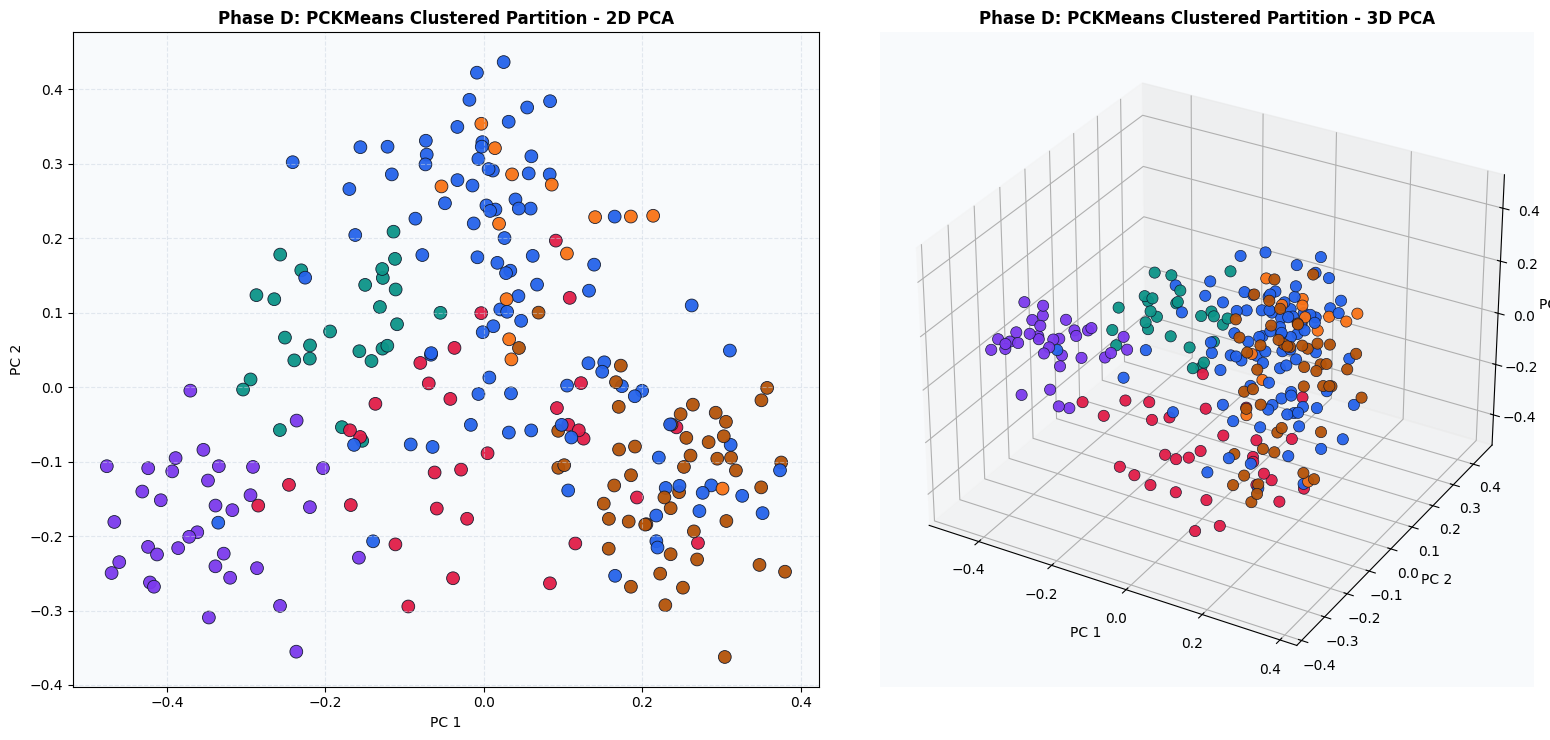

In [14]:
plot_embeddings_2d_3d(
    embeddings=pipeline.embeddings,
    labels=pipeline.labels,
    title_prefix="Phase D: PCKMeans Clustered Partition",
    random_state=RANDOM_STATE
)